# CardioIA · Fase 2 · Parte 2: classificador de risco por texto

Simulação de triagem: o modelo lê uma frase com sintomas e classifica o caso como **alto risco** ou **baixo risco**.

Etapas: base rotulada (`data/frases_risco.csv`) → vetorização TF-IDF → Regressão Logística → avaliação (acurácia, sensibilidade, matriz de confusão) → frases-armadilha para expor vieses e distorções.

**No Colab:** clone o repositório primeiro e ajuste `RAIZ` para a pasta clonada.
```python
!git clone https://github.com/souzaleite-dev/CardioIA-Fase2.git
RAIZ = Path('CardioIA-Fase2')
```

> Material educacional. Não é dispositivo médico e não deve apoiar decisão sobre paciente real.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (ConfusionMatrixDisplay, accuracy_score, classification_report,
                             make_scorer, recall_score)
from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_validate, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.tree import DecisionTreeClassifier

pd.set_option('display.max_colwidth', None)
RAIZ = Path.cwd().parent  # ajuste para Path('CardioIA-Fase2') no Colab

frases = pd.read_csv(RAIZ / 'data' / 'frases_risco.csv')
print(frases.shape)
frases['situacao'].value_counts()

(150, 2)


situacao
alto risco     75
baixo risco    75
Name: count, dtype: int64

## 1. Base rotulada

150 frases curtas, na voz do paciente (ou de um acompanhante), balanceadas: 75 de **alto risco** e 75 de **baixo risco**.

**Critério de rotulagem**, inspirado nos sinais de alarme usados em triagem (discriminadores das cores vermelha e laranja do Protocolo de Manchester e sinais de alerta de infarto e AVC):

| alto risco | baixo risco |
|---|---|
| dor ou aperto no peito em repouso, intenso, irradiado ou com suor frio, náusea ou falta de ar | dor localizada que piora ao toque ou ao movimento, com causa evidente (treino, pancada, postura) |
| falta de ar em repouso, ao deitar ou de início súbito | cansaço com causa evidente (noite mal dormida, semana puxada) |
| desmaio, quase desmaio, palpitação com tontura | palpitação curta depois de café, susto ou nervosismo |
| boca torta, fala enrolada, fraqueza ou dormência súbita de um lado | queixas leves de outros sistemas (resfriado, azia, dente) |
| pressão muito alta com sintomas, tosse com sangue | rotina: receita, check-up, pressão controlada |

Cerca de 30 das 75 frases de baixo risco usam **vocabulário cardíaco benigno** ("o coração acelerou depois que tomei três cafés", "dor no peito que piora quando aperto o local"). Sem isso, o modelo separaria as classes pelo *tema* da frase e a acurácia sairia inflada.

O teste (25%) é separado antes de qualquer ajuste, com a mesma proporção de classes:

In [2]:
X_treino, X_teste, y_treino, y_teste = train_test_split(
    frases['frase'], frases['situacao'], test_size=0.25, stratify=frases['situacao'], random_state=42)
print(len(X_treino), 'frases de treino |', len(X_teste), 'frases de teste')

112 frases de treino | 38 frases de teste


## 2. TF-IDF: frases viram vetores

Cada frase vira um vetor com um peso por palavra do vocabulário:

- **TF** (*term frequency*): quanto a palavra aparece na frase;
- **IDF** (*inverse document frequency*): quão rara ela é na base. Palavras presentes em quase toda frase ("de", "com") pesam pouco; palavras raras e distintivas pesam mais.

Configuração: `strip_accents='unicode'`, para "tórax" e "torax" virarem o mesmo termo. **Sem remoção de *stopwords***: as listas prontas em português (como a do NLTK) incluem "não" e "sem", o que apagaria a negação da frase.

In [3]:
tfidf = TfidfVectorizer(strip_accents='unicode')
matriz = tfidf.fit_transform(X_treino)
print('matriz de treino:', matriz.shape, '(frases × termos do vocabulário)')

# pesos da primeira frase de treino: só os termos presentes nela são diferentes de zero;
# "lombar" (rara na base) pesa mais que "dor" (comum)
pesos_frase = pd.Series(matriz[0].toarray()[0], index=tfidf.get_feature_names_out())
print('frase:', X_treino.iloc[0])
pesos_frase[pesos_frase > 0].sort_values(ascending=False).round(3)

matriz de treino: (112, 372) (frases × termos do vocabulário)
frase: sinto dor na lombar quando fico muito tempo sentado


lombar     0.465
sentado    0.427
tempo      0.363
fico       0.363
quando     0.307
na         0.299
muito      0.257
sinto      0.218
dor        0.198
dtype: float64

## 3. Escolha do modelo

Comparação por **validação cruzada estratificada (5 dobras) só no treino**; o teste fica intocado para a avaliação final. O TF-IDF fica dentro do `Pipeline`, então é reajustado a cada dobra e o vocabulário da dobra de validação não vaza para o treino.

Duas métricas: **acurácia** e **sensibilidade para alto risco** (fração dos casos graves que o modelo pega). Em triagem, mandar para casa um paciente grave custa mais caro que um alarme falso.

In [4]:
dobras = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
metricas = {'acurácia': 'accuracy',
            'sensibilidade (alto risco)': make_scorer(recall_score, pos_label='alto risco')}
candidatos = {
    'Regressão Logística · palavras': make_pipeline(
        TfidfVectorizer(strip_accents='unicode'), LogisticRegression()),
    'Regressão Logística · palavras + bigramas': make_pipeline(
        TfidfVectorizer(strip_accents='unicode', ngram_range=(1, 2)), LogisticRegression()),
    'Árvore de Decisão · palavras': make_pipeline(
        TfidfVectorizer(strip_accents='unicode'), DecisionTreeClassifier(random_state=42)),
}
comparacao = {}
for nome, pipeline in candidatos.items():
    r = cross_validate(pipeline, X_treino, y_treino, cv=dobras, scoring=metricas)
    comparacao[nome] = {m: f"{r['test_' + m].mean():.2f} ± {r['test_' + m].std():.2f}" for m in metricas}
pd.DataFrame(comparacao).T

,acurácia,sensibilidade (alto risco)
Regressão Logística · palavras,0.83 ± 0.06,0.89 ± 0.04
Regressão Logística · palavras + bigramas,0.80 ± 0.07,0.87 ± 0.09
Árvore de Decisão · palavras,0.76 ± 0.15,0.75 ± 0.14


**Escolha: Regressão Logística com palavras simples.** Teve a maior acurácia e a maior sensibilidade, com a menor variação entre dobras. A árvore oscila muito (±0,15 na acurácia): com 112 frases, cada divisão depende de poucas palavras e muda com a amostra. Bigramas ("falta de", "no peito") não ajudaram nesta base pequena; multiplicam as colunas sem trazer exemplos novos. A Regressão Logística tem ainda uma vantagem importante em saúde: cada palavra recebe um peso legível, o que permite auditar o que o modelo aprendeu (seção 5).

## 4. Treino e teste

Acurácia no teste: 89.5%

              precision    recall  f1-score   support

  alto risco       0.89      0.89      0.89        19
 baixo risco       0.89      0.89      0.89        19

    accuracy                           0.89        38
   macro avg       0.89      0.89      0.89        38
weighted avg       0.89      0.89      0.89        38



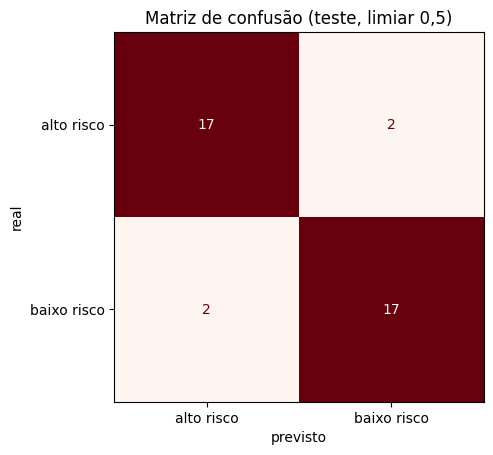

In [5]:
modelo = candidatos['Regressão Logística · palavras'].fit(X_treino, y_treino)
ALTO = list(modelo.classes_).index('alto risco')

previsto = modelo.predict(X_teste)
print(f'Acurácia no teste: {accuracy_score(y_teste, previsto):.1%}\n')
print(classification_report(y_teste, previsto, digits=2))
ConfusionMatrixDisplay.from_predictions(y_teste, previsto, cmap='Reds', colorbar=False)
plt.title('Matriz de confusão (teste, limiar 0,5)')
plt.xlabel('previsto')
plt.ylabel('real')
plt.show()

In [6]:
p_alto_teste = modelo.predict_proba(X_teste)[:, ALTO]
erros = pd.DataFrame({'frase': X_teste, 'real': y_teste, 'previsto': previsto,
                      'p(alto risco)': p_alto_teste.round(2)}).query('real != previsto')
erros

,frase,real,previsto,p(alto risco)
67,dor no peito e tosse com sangue depois de uma cirurgia no joelho,alto risco,baixo risco,0.49
32,acordo sufocado à noite e preciso de três travesseiros para dormir,alto risco,baixo risco,0.44
134,queria medir a pressão só para conferir,baixo risco,alto risco,0.53
85,minha pressão está controlada e vim para a consulta de rotina,baixo risco,alto risco,0.60


**Leitura:** 89,5% de acurácia (34 de 38) e sensibilidade de 0,89: 2 dos 19 casos graves do teste passariam como baixo risco. Os 4 erros têm P(alto) entre 0,44 e 0,60, perto da fronteira de 0,5: o modelo estava em dúvida.

- *"dor no peito e tosse com sangue depois de uma cirurgia no joelho"* (quadro sugestivo de embolia pulmonar) virou **baixo risco**. A palavra "depois" é o termo que mais puxa para baixo risco (seção 5);
- *"acordo sufocado à noite e preciso de três travesseiros para dormir"* (ortopneia, sinal de insuficiência cardíaca) virou **baixo risco**: "sufocado" e "travesseiros" não aparecem em nenhuma frase de treino. O modelo não reconhece o que nunca viu;
- *"minha pressão está controlada..."* e *"queria medir a pressão só para conferir"* viraram **alto risco**, empurradas por "minha", "está" e "para", palavras sem conteúdo clínico.

## 5. O que o modelo aprendeu

Na Regressão Logística cada termo tem um peso: negativo empurra para `alto risco` (`modelo.classes_[0]`), positivo para `baixo risco`. Os mais fortes de cada lado:

In [7]:
pesos = pd.Series(modelo[-1].coef_[0], index=modelo[0].get_feature_names_out())  # positivo favorece classes_[1]
print('classes:', list(modelo.classes_))
pd.DataFrame({'empurram para alto risco': pesos.nsmallest(12).index,
              'empurram para baixo risco': pesos.nlargest(12).index})

classes: ['alto risco', 'baixo risco']


,empurram para alto risco,empurram para baixo risco
0,peito,depois
1,ar,quando
2,falta,leve
3,esta,sinto
4,forte,na
5,nao,pe
6,repente,nariz
7,para,tempo
8,coracao,fico
9,respirar,comer


In [8]:
# em quantas frases de treino de cada classe aparecem algumas dessas palavras
analisador = modelo[0].build_analyzer()
tokens = X_treino.map(lambda frase: set(analisador(frase)))
pd.DataFrame({palavra: tokens.map(lambda t: palavra in t).groupby(y_treino).sum()
              for palavra in ['nao', 'sem', 'depois', 'para', 'minha', 'esta']}).T

situacao,alto risco,baixo risco
nao,6,0
sem,4,2
depois,2,19
para,7,1
minha,6,1
esta,9,1


In [9]:
# a frase de embolia que o modelo errou no teste, trocando só "depois de" por "após"
for frase in ['dor no peito e tosse com sangue depois de uma cirurgia no joelho',
              'dor no peito e tosse com sangue após uma cirurgia no joelho']:
    print(f"P(alto) = {modelo.predict_proba([frase])[0][ALTO]:.2f} | {frase}")

P(alto) = 0.49 | dor no peito e tosse com sangue depois de uma cirurgia no joelho
P(alto) = 0.58 | dor no peito e tosse com sangue após uma cirurgia no joelho


Parte do que o modelo aprendeu faz sentido clínico: "peito", "falta", "ar", "forte", "repente", "respirar", "frio" (de suor frio). A outra parte é **atalho estatístico** (*shortcut learning*), artefato de como a base foi escrita:

- **"nao" é um dos termos mais fortes de alto risco.** Aparece em frases graves ("não passa", "não consigo respirar") e em nenhuma frase leve do treino. O modelo concluiu que "não" indica gravidade, o oposto do que acontece numa negação como "não sinto dor".
- **"esta", "para", "minha"** não têm conteúdo clínico; refletem o estilo de redação das frases graves ("minha boca ficou torta", "a fala está enrolada").
- **"depois", "quando", "sinto"** puxam para baixo risco pelo mesmo motivo: as frases leves foram escritas com a causa explícita ("depois da academia", "quando aperto o local"). Na frase de embolia do teste, trocar só "depois de" por "após" leva P(alto) de 0,49 para 0,58 e muda a classificação: uma preposição decide a triagem.

Com 150 frases escritas por uma única pessoa, o modelo aprende também o **estilo de quem escreveu**. É o viés do rotulador, invisível na acurácia.

## 6. Limiar de decisão: sensibilidade × especificidade

O `predict` usa limiar 0,5: alto risco se P(alto) ≥ 0,5. Em triagem vale baixar o limiar e aceitar mais alarmes falsos em troca de perder menos casos graves. Para não escolher o limiar olhando o teste, as probabilidades abaixo vêm da validação cruzada **no treino** (cada frase é prevista por um modelo que não a viu):

In [10]:
p_alto_validacao = cross_val_predict(modelo, X_treino, y_treino, cv=dobras, method='predict_proba')[:, ALTO]
linhas = []
for limiar in [0.50, 0.45, 0.40, 0.35]:
    rotulo = np.where(p_alto_validacao >= limiar, 'alto risco', 'baixo risco')
    linhas.append({'limiar': limiar,
                   'sensibilidade (alto)': recall_score(y_treino, rotulo, pos_label='alto risco'),
                   'especificidade (baixo)': recall_score(y_treino, rotulo, pos_label='baixo risco'),
                   'acurácia': accuracy_score(y_treino, rotulo)})
pd.DataFrame(linhas).round(2)

,limiar,sensibilidade (alto),especificidade (baixo),acurácia
0,0.50,0.89,0.77,0.83
1,0.45,0.98,0.68,0.83
2,0.40,0.98,0.50,0.74
3,0.35,1.00,0.32,0.66


Com limiar **0,45** a sensibilidade sobe de 0,89 para 0,98 sem perder acurácia; abaixo disso a especificidade despenca. Aplicando 0,45 ao teste:

acurácia 81.6% | sensibilidade 0.95 | especificidade 0.68


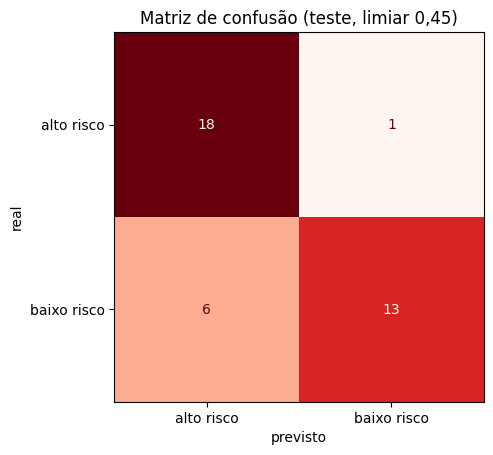

In [11]:
LIMIAR = 0.45
previsto_limiar = np.where(p_alto_teste >= LIMIAR, 'alto risco', 'baixo risco')
print(f'acurácia {accuracy_score(y_teste, previsto_limiar):.1%} | '
      f'sensibilidade {recall_score(y_teste, previsto_limiar, pos_label="alto risco"):.2f} | '
      f'especificidade {recall_score(y_teste, previsto_limiar, pos_label="baixo risco"):.2f}')
ConfusionMatrixDisplay.from_predictions(y_teste, previsto_limiar, cmap='Reds', colorbar=False)
plt.title('Matriz de confusão (teste, limiar 0,45)')
plt.xlabel('previsto')
plt.ylabel('real')
plt.show()

No teste, a sensibilidade vai de 0,89 para 0,95 (só 1 caso grave escapa) e a especificidade cai de 0,89 para 0,68: os alarmes falsos passam de 2 para 6 das 19 frases leves, e a acurácia cai para 81,6%. Para triagem é a troca certa: o alarme falso custa uma avaliação a mais; o falso negativo pode custar uma vida. Daqui em diante o modelo usa `LIMIAR = 0.45`.

## 7. Frases-armadilha: vieses e distorções

Frases novas, fora da base, escritas para testar pontos fracos conhecidos de modelos de texto. O rótulo esperado segue o critério da seção 1.

In [12]:
armadilhas = pd.DataFrame([
    ('negação', 'não sinto dor no peito nem falta de ar, só vim renovar a receita', 'baixo risco'),
    ('negação', 'estou sem dor no peito e sem falta de ar hoje', 'baixo risco'),
    ('apresentação atípica (comum em mulheres)', 'sinto enjoo, suor frio e uma dor estranha na mandíbula desde cedo', 'alto risco'),
    ('apresentação atípica (diabetes)', 'sou diabética e desde ontem estou com um cansaço enorme e enjoo, sem dor', 'alto risco'),
    ('intensidade enganosa', 'dor leve no peito com suor frio e enjoo', 'alto risco'),
    ('"peito" benigno', 'dor no peito só quando aperto o músculo depois da academia', 'baixo risco'),
    ('linguagem regional', 'tô com uma agonia no peito e o braço formigando', 'alto risco'),
    ('linguagem coloquial', 'o coração tá dando uns pulos e a vista escureceu', 'alto risco'),
    ('erro de digitação', 'dor no peitu e farta de ar', 'alto risco'),
    ('jargão médico', 'precordialgia com irradiação para membro superior esquerdo e sudorese', 'alto risco'),
    ('palavra assustadora, sem sintoma', 'tenho medo de infartar como meu pai, mas estou sem sintomas', 'baixo risco'),
    ('contexto benigno', 'fiz um check-up do coração e está tudo normal', 'baixo risco'),
], columns=['tipo', 'frase', 'esperado'])

p_alto = modelo.predict_proba(armadilhas['frase'])[:, ALTO]
armadilhas['p(alto risco)'] = p_alto.round(2)
armadilhas['previsto'] = np.where(p_alto >= LIMIAR, 'alto risco', 'baixo risco')
armadilhas['acertou'] = armadilhas['previsto'] == armadilhas['esperado']
print(f"acertos: {armadilhas['acertou'].sum()} de {len(armadilhas)}")
armadilhas

acertos: 9 de 12


,tipo,frase,esperado,p(alto risco),previsto,acertou
0,negação,"não sinto dor no peito nem falta de ar, só vim renovar a receita",baixo risco,0.67,alto risco,False
1,negação,estou sem dor no peito e sem falta de ar hoje,baixo risco,0.76,alto risco,False
2,apresentação atípica (comum em mulheres),"sinto enjoo, suor frio e uma dor estranha na mandíbula desde cedo",alto risco,0.50,alto risco,True
3,apresentação atípica (diabetes),"sou diabética e desde ontem estou com um cansaço enorme e enjoo, sem dor",alto risco,0.51,alto risco,True
4,intensidade enganosa,dor leve no peito com suor frio e enjoo,alto risco,0.66,alto risco,True
5,"""peito"" benigno",dor no peito só quando aperto o músculo depois da academia,baixo risco,0.39,baixo risco,True
6,linguagem regional,tô com uma agonia no peito e o braço formigando,alto risco,0.66,alto risco,True
7,linguagem coloquial,o coração tá dando uns pulos e a vista escureceu,alto risco,0.59,alto risco,True
8,erro de digitação,dor no peitu e farta de ar,alto risco,0.68,alto risco,True
9,jargão médico,precordialgia com irradiação para membro superior esquerdo e sudorese,alto risco,0.66,alto risco,True


In [13]:
# palavras das armadilhas que o modelo nunca viu no treino (viram zero no vetor)
vocabulario = set(modelo[0].get_feature_names_out())
desconhecidas = {frase: [t for t in analisador(frase) if t not in vocabulario] for frase in armadilhas['frase'][6:10]}

# frase só com palavras desconhecidas: vetor todo zero, sobra apenas o intercepto do modelo
print('P(alto) de uma frase sem nenhuma palavra conhecida:', modelo.predict_proba(['xablau quiproquó'])[0][ALTO].round(2))
desconhecidas

P(alto) de uma frase sem nenhuma palavra conhecida: 0.48


{'tô com uma agonia no peito e o braço formigando': ['to', 'agonia'],
 'o coração tá dando uns pulos e a vista escureceu': ['ta',
  'dando',
  'uns',
  'pulos'],
 'dor no peitu e farta de ar': ['peitu', 'farta'],
 'precordialgia com irradiação para membro superior esquerdo e sudorese': ['precordialgia',
  'irradiacao',
  'membro',
  'superior',
  'sudorese']}

**9 de 12 acertos, e os 3 erros são alarmes falsos.** Mas os acertos pedem uma segunda leitura:

- **Negação (2 erros).** "não sinto dor no peito nem falta de ar" recebe P(alto) = 0,67, e "sem dor no peito e sem falta de ar", 0,76, mais que muitas frases graves de verdade. TF-IDF é um *saco de palavras*: vê "peito", "falta" e "ar" e ignora a ordem; "não" e "sem" ainda somam risco (seção 5). A Parte 1 deste projeto trata a negação com regra explícita; o classificador, não.
- **Apresentações atípicas no limite.** O infarto com enjoo, suor frio e dor na mandíbula, quadro frequente em mulheres, ficou com P = 0,50; o da paciente diabética, 0,51. Com o limiar padrão de 0,5 o primeiro já seria baixo risco. A base retrata o infarto "clássico" (dor no peito irradiando para o braço), descrição que a literatura construiu sobre coortes majoritariamente masculinas: o mesmo viés de sexo apontado na Fase 1, onde a base numérica tem 61% de homens.
- **Acertos pelo motivo errado.** No jargão "precordialgia com irradiação para membro superior esquerdo e sudorese", 5 dos 8 termos não existem no vocabulário; o alto risco veio de "para", "com" e "esquerdo". Em "dor no peitu e farta de ar", o erro de digitação apagou duas palavras e o resultado se apoiou em "ar". Funcionou, mas por sorte, e sorte não é critério clínico.
- **Linguagem do paciente.** Em "tô com uma agonia no peito" e "o coração tá dando uns pulos", as palavras "tô", "agonia", "tá" e "pulos" são desconhecidas; o acerto dependeu de "peito", "formigando" e "vista escureceu" estarem na frase. Uma queixa feita só com palavras fora do vocabulário vira vetor zero e recebe P(alto) ≈ 0,48, praticamente cara ou coroa. O viés atinge justamente quem fala diferente de quem escreveu a base: outra região, outra escolaridade.
- **Contexto benigno com palavra cardíaca.** "fiz um check-up do coração e está tudo normal" virou alto risco por causa de "coração" e "está".

## 8. Vieses, responsabilidade e o que mudaria

| Viés ou distorção | Evidência neste notebook | Mitigação |
|---|---|---|
| Negação ignorada | as 2 armadilhas de negação viram alto risco | marcar a negação no pré-processamento (como faz a Parte 1) ou usar modelos que leem contexto, como o BERTimbau |
| Viés do rotulador (estilo de escrita) | "para", "esta", "minha" e "depois" entre os termos mais fortes | frases de pacientes reais, de várias pessoas, rotuladas por profissionais com concordância medida |
| Sub-representação de apresentações atípicas | infarto atípico com P(alto) = 0,50 | incluir quadros típicos de mulheres, idosos e diabéticos e medir a sensibilidade por subgrupo |
| Vocabulário fechado (linguagem do paciente) | jargão, regionalismo e erro de digitação viram palavras desconhecidas; frase toda desconhecida recebe P ≈ 0,48 | frases de pacientes de várias regiões e escolaridades, n-gramas de caracteres, correção ortográfica |
| Base pequena | variação de ±0,06 na acurácia entre dobras | ampliar a base antes de qualquer conclusão |

**Responsabilidade.** Este classificador é demonstração de pipeline, não ferramenta clínica. Mesmo um modelo melhor serviria só como **apoio**: em triagem real o profissional de saúde decide, o limiar é escolhido priorizando sensibilidade e cada previsão precisa ser auditável. Por isso a Regressão Logística, com pesos legíveis, foi preferida a modelos mais opacos.

## 9. Teste você mesmo

In [14]:
def classificar(frase, limiar=LIMIAR):
    """Rótulo e P(alto risco) para uma frase nova."""
    p = modelo.predict_proba([frase])[0][ALTO]
    return ('alto risco' if p >= limiar else 'baixo risco'), round(float(p), 2)


for frase in ['sinto um aperto no peito e estou suando frio',
              'estou com o nariz entupido desde ontem']:
    print(classificar(frase), '|', frase)

('alto risco', 0.61) | sinto um aperto no peito e estou suando frio
('baixo risco', 0.39) | estou com o nariz entupido desde ontem


## Conclusão

O pipeline TF-IDF + Regressão Logística chega a 89,5% de acurácia no teste com só 150 frases, número que parece bom e esconde três problemas: não entende negação, aprendeu o estilo de quem escreveu a base e trata apresentações atípicas de infarto como caso de fronteira. Em triagem, a métrica que importa é a sensibilidade; por isso o limiar foi deslocado para 0,45, e nenhum caso grave das frases-armadilha passou despercebido. A lição da fase vale mais que o número: acurácia alta, sozinha, não diz se o modelo é seguro.